<a href="https://colab.research.google.com/github/ingredy3/SSD_1/blob/main/Vfinal1_Aprimorada_MVP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Predição de Preço de Veículos Usados
**Disciplina:** Sistemas de Suporte à Decisão  
**Aluno(a):** Ingredy Thamis  
**Data:** 29 de Setembro de 2025

---

## 1. Definição do Problema
O objetivo deste trabalho é construir um **MVP** (Produto Mínimo Viável) de um sistema de suporte à decisão que seja capaz de **estimar o preço de venda de veículos usados (`sellingprice`)** com base em características observáveis como ano de fabricação, quilometragem, condição, marca, modelo, etc.

---

## 2. Hipótese
**Tipo de tarefa:** Regressão supervisionada (variável alvo contínua).
- Hipótese principal: variáveis como idade do carro, quilometragem, marca/modelo e condição são capazes de explicar boa parte da variação do preço.
- Hipótese adicional: a variável `mmr` apresenta **data leakage** (correlação ≈ 0.98 com o preço), portanto não deve ser utilizada no modelo final.

---

## 3. Conjunto de Dados
- Arquivo: `car_prices.csv` (reduzido para ~150.000 registros e hospedado no GitHub).
- Variável alvo: `sellingprice` (valor de venda do veículo).
- Principais variáveis utilizadas: `year`, `make`, `model`, `body`, `transmission`, `condition`, `odometer`, `color`, `interior`, `state`, `vehicle_age`.

---

## 4. Metodologia
O processo foi dividido em etapas:
1. Importação das bibliotecas.
2. Carregamento e amostragem do dataset.
3. Criação da variável `vehicle_age`.
4. Limpeza de dados (ex.: `odometer`).
5. Redução de cardinalidade em variáveis categóricas.
6. Pré-processamento (imputação, normalização e One-Hot Encoding).
7. Teste de modelos: Baseline, Regressão Linear, Random Forest.
8. Avaliação por métricas (MAE, RMSE, R²).
9. Análise de importância de variáveis.

**PASSO 1**

In [1]:
# PASSO 1 - IMPORTAR BIBLIOTECAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import joblib
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


**Explicação detalhada (Passo 1)**

- `import pandas as pd` — importa o pandas, usado para ler e manipular tabelas (DataFrame).
- `import numpy as np` — importa numpy, necessário para operações numéricas, vetoriais e funções matemáticas.
- `import matplotlib.pyplot as plt` e `%matplotlib inline` — usadas para gerar gráficos dentro do notebook.
- `train_test_split, RandomizedSearchCV` — funções para dividir dados e fazer busca aleatória de hiperparâmetros.
- `SimpleImputer, StandardScaler, OneHotEncoder` — ferramentas para imputação de dados, padronização e codificação de variáveis categóricas.
- `ColumnTransformer, Pipeline` — aplicam transformações específicas por coluna e encadeiam pré-processamento + modelo.
- `DummyRegressor, LinearRegression, RandomForestRegressor` — modelos testados: baseline, linear e Random Forest
- `mean_absolute_error, mean_squared_error, r2_score` — métricas para avaliar desempenho de regressão.
- `permutation_importance` — método para medir importância das features.
- `joblib` — salvar/carregar o pipeline final.
- `warnings.filterwarnings('ignore')` — suprime avisos para saída mais limpa (durante desenvolvimento, pode reativar).

**Por que cada coisa está aqui?**  
Essas bibliotecas formam a base do fluxo: leitura/EDA → limpeza → pré-processamento → modelagem → avaliação → salvamento. `Pipeline` + `ColumnTransformer` garantem reprodutibilidade do pré-processamento e evitam data leakage.


**PASSO 2**

In [2]:
# PASSO 2 - CARREGAR DATASET
# Utilizamos o link raw do GitHub para evitar upload manual.
url = "https://raw.githubusercontent.com/ingredy3/SSD_1/refs/heads/main/car_prices.csv"
df = pd.read_csv(url)
print('Shape do dataset:', df.shape)
df.head()

Shape do dataset: (149999, 16)


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500,27750,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000,67000,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


**Explicação detalhada (Passo 2)**

- `url` — endereço raw do CSV no GitHub; mantém o notebook portátil e fácil de reproduzir.
- `pd.read_csv(url)` — lê o CSV e retorna um DataFrame 'df'.
- `df.shape` — imprime o número de linhas e colunas; ajuda a confirmar que o arquivo foi carregado corretamente.
- `df.head()` — mostra as primeiras linhas para verificar nomes de colunas e tipos aparentes.

**Por que?**  
Carregar os dados é o passo inicial: sem dados não há análise. Sempre verifique `shape` e `head()` para garantir que a leitura ocorreu como esperado (filtros de encoding, separador etc.).


**PASSO 3**

In [3]:
# PASSO 3 - EDA RÁPIDA (Exploração inicial)
# Tipos e contagem não nula
display(df.info())

# Estatísticas descritivas (todas as colunas)
display(df.describe(include='all').T)

# Contagem de nulos por coluna (ordenado)
nulls = df.isnull().sum().sort_values(ascending=False)
display(nulls.head(40))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149999 entries, 0 to 149998
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          149999 non-null  int64  
 1   make          148858 non-null  object 
 2   model         148830 non-null  object 
 3   trim          148529 non-null  object 
 4   body          145985 non-null  object 
 5   transmission  132413 non-null  object 
 6   vin           149999 non-null  object 
 7   state         149999 non-null  object 
 8   condition     138207 non-null  float64
 9   odometer      149922 non-null  float64
 10  color         149742 non-null  object 
 11  interior      149742 non-null  object 
 12  seller        149999 non-null  object 
 13  mmr           149999 non-null  int64  
 14  sellingprice  149999 non-null  int64  
 15  saledate      149999 non-null  object 
dtypes: float64(2), int64(3), object(11)
memory usage: 18.3+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,149999.0,NaN,NaN,NaN,2009.470816,4.182271,1984.0,2007.0,2011.0,2013.0,2015.0
make,148858,94,Ford,24147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,148830,912,Altima,4708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trim,148529,1756,Base,15748,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,145985,45,Sedan,64358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,132413,2,automatic,127397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vin,149999,149203,wddng71x47a041960,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,149999,36,ca,24397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,138207.0,NaN,NaN,NaN,29.82545,13.757659,1.0,22.0,34.0,41.0,49.0
odometer,149922.0,NaN,NaN,NaN,73130.641093,56617.981749,1.0,28877.25,58006.0,107773.25,999999.0


,0
transmission,17586
condition,11792
body,4014
trim,1470
model,1169
make,1141
color,257
interior,257
odometer,77
state,0


**Explicação detalhada (Passo 3)**

- `df.info()` — mostra tipos das colunas e quantos valores não-nulos cada uma possui; útil para detectar colunas com muitos nulos.
- `df.describe(include='all').T` — estatísticas descritivas (contagem, média, std, min, max, quartis); `.T` (transposto) melhora a leitura.
- `df.isnull().sum().sort_values()` — soma valores nulos por coluna e ordena do maior para o menor; mostra quais colunas precisam de atenção.

**Por que?**  
Entender a qualidade e distribuição dos dados é essencial antes de qualquer limpeza ou modelagem. Essa etapa orienta estratégias de imputação, tratamento de outliers e seleção de features.


**PASSO 4**

In [4]:
# PASSO 4 - AMOSTRAGEM (usar apenas durante desenvolvimento)
RANDOM_STATE = 42
# Para desenvolvimento rápido, pegamos 10% da base. Remova/comment esta linha para treinar com 100%.
df = df.sample(frac=0.1, random_state=RANDOM_STATE).reset_index(drop=True)
print('Shape após amostragem:', df.shape)

Shape após amostragem: (15000, 16)


**Explicação detalhada (Passo 4)**

- `df.sample(frac=0.1, random_state=42)` — seleciona aleatoriamente 10% dos registros para reduzir tempo de execução durante desenvolvimento.
- `reset_index(drop=True)` — reorganiza os índices do DataFrame resultante.
- `print(...)` — confirma o novo tamanho.

**Por que?**  
Amostragem acelera experimentos iterativos. Importante: para resultados finais e relatório, remova a amostragem e treine com a base completa.


**PASSO 5**

In [5]:
# PASSO 5 - SELEÇÃO DE COLUNAS (sem 'mmr' para evitar vazamento)
candidate_cols = ['year','make','model','trim','body','transmission','condition','odometer','mmr','color','interior','state']
cols = [c for c in candidate_cols if c in df.columns]  # mantém apenas colunas existentes
target = 'sellingprice'

# Remover 'mmr' por ser altamente correlacionada com o target (data leakage)
if 'mmr' in cols:
    cols.remove('mmr')

df = df[cols + [target]].copy()
print('Colunas mantidas para modelagem:', cols + [target])

Colunas mantidas para modelagem: ['year', 'make', 'model', 'trim', 'body', 'transmission', 'condition', 'odometer', 'color', 'interior', 'state', 'sellingprice']


**Explicação detalhada (Passo 5)**

- `candidate_cols` — lista inicial de features que consideramos relevantes.
- `cols = [c for c in candidate_cols if c in df.columns]` — filtro para evitar erro caso alguma coluna não exista.
- `target = 'sellingprice'` — variável alvo.
- Removemos `'mmr'` explicitamente porque ela tem correlação muito alta com `sellingprice` e poderia causar *data leakage* (modelo aprenderia algo que não estará disponível em produção).
- `df = df[cols + [target]].copy()` — seleciona somente as colunas de interesse e cria cópia para evitar *chained assignments*.

**Por que?**  
Escolher features relevantes e evitar vazamento de informação é fundamental para um modelo confiável e aplicável em produção.


**PASSO 6**

In [6]:
# PASSO 6 - CRIAR 'vehicle_age'
# Transformação simples: idade = 2025 - ano de fabricação
df['vehicle_age'] = 2025 - df['year']
# Limitar valores para evitar negativos e extremos
df['vehicle_age'] = df['vehicle_age'].clip(lower=0, upper=100)
df[['year','vehicle_age']].head()

,year,vehicle_age
0,2002,23
1,2006,19
2,2008,17
3,2012,13
4,2011,14


**Explicação detalhada (Passo 6)**

- `df['vehicle_age'] = 2025 - df['year']` — cria nova feature que representa a idade do veículo.
- `clip(lower=0, upper=100)` — evita idades negativas (erro de digitação) e limita extremos.
- Exibir `[['year','vehicle_age']].head()` — verificar resultado da transformação.

**Por que?**  
A idade é intuitiva e frequentemente explicativa do preço: quanto mais velho, menor o valor. Usar uma feature explícita facilita interpretação do modelo.


**PASSO 7**

In [7]:
# PASSO 7 - TRATAR 'odometer' (quilometragem)
# Valores fora do intervalo plausível virarão NaN e serão imputados depois
df['odometer'] = df['odometer'].where((df['odometer'] >= 100) & (df['odometer'] <= 500000))
df['odometer'].describe()

,odometer
count,14913.000000
mean,72525.051834
std,54803.073710
min,174.000000
25%,28831.000000
50%,57105.000000
75%,106917.000000
max,450825.000000


**Explicação detalhada (Passo 7)**

- `where((...))` — mantém apenas valores entre 100 e 500000; valores fora tornam-se NaN.
- `describe()` — examina estatísticas após limpeza (média, min, max, quartis).

**Por que?**  
Quilometragens absurdas (ex.: 999999) são geralmente erros de registro e podem prejudicar o aprendizado. Marcá-las como NaN e imputá-las posteriormente é mais seguro.


**PASSO 8**

In [8]:
# PASSO 8 - PREPARAR DATASET FINAL PARA MODELAGEM
df_model = df.copy()
# Remover linhas sem target (sellingprice)
df_model = df_model[df_model[target].notna()].reset_index(drop=True)
print('Shape do df_model:', df_model.shape)
df_model.head()

Shape do df_model: (15000, 13)


,year,make,model,trim,body,transmission,condition,odometer,color,interior,state,sellingprice,vehicle_age
0,2002,Toyota,Camry,LE,Sedan,automatic,19.0,185100.0,red,tan,fl,2700,23
1,2006,Pontiac,Grand Prix,GT,Sedan,automatic,19.0,118061.0,red,black,fl,3300,19
2,2008,BMW,3 Series,328i,Convertible,automatic,4.0,56765.0,white,beige,ca,17500,17
3,2012,Volkswagen,Jetta,SE PZEV,Sedan,automatic,27.0,41015.0,black,black,ca,11250,13
4,2011,Ford,F-150,FX2,SuperCab,automatic,39.0,24766.0,—,black,tn,24000,14


**Explicação detalhada (Passo 8)**

- `df_model = df.copy()` — cópia para preservar o dataset original.
- `df_model[df_model[target].notna()]` — mantém apenas registros que têm preço (target).
- `reset_index(drop=True)` — reorganiza índices após filtragem.
- Exibir `shape` e `head()` para confirmação.

**Por que?**  
Treinar requer valores do target; registros sem `sellingprice` não contribuem para aprendizado supervisionado e devem ser removidos.


**PASSO 9**

In [9]:
# PASSO 9 - REDUZIR CARDINALIDADE DE 'make' e 'model'
def keep_top_n(series, top_n=80):
    top = series.value_counts().nlargest(top_n).index
    return series.where(series.isin(top), other='other')

for c in ['make','model']:
    if c in df_model.columns:
        df_model[c] = keep_top_n(df_model[c], top_n=80)

# Verificar resultado
df_model[['make','model']].head()

,make,model
0,Toyota,Camry
1,Pontiac,other
2,BMW,3 Series
3,Volkswagen,Jetta
4,Ford,F-150


**Explicação detalhada (Passo 9)**

- `keep_top_n` — função que mantém as `top_n` categorias mais frequentes e substitui as demais por `'other'`.
- Aplicamos em `make` e `model` porque elas possuem alta cardinalidade (muitas categorias únicas).
- Mostramos as primeiras linhas para conferir a transformação.

**Por que?**  
OneHotEncoder expande cada categoria para uma coluna; ao reduzir cardinalidade evitamos explosão dimensional, redução de memória e overfitting em categorias raras.


**PASSO 10**

In [10]:
# PASSO 10 - DIVISÃO TREINO / VALIDAÇÃO / TESTE (80% / 10% / 10%)
X = df_model.drop(columns=[target])
y = df_model[target]

# Primeiro separa 20% (validação + teste)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Depois divide o restante em 80% treino e 10% val (do total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)
# Observação: 0.125 * 0.8 = 0.1 do total  -> resultados: 0.8 train, 0.1 val, 0.1 test

print('Shapes -> Treino:', X_train.shape, 'Validação:', X_val.shape, 'Teste:', X_test.shape)

Shapes -> Treino: (10500, 12) Validação: (1500, 12) Teste: (3000, 12)


**Explicação detalhada (Passo 10)**

- `X = df_model.drop(columns=[target])` e `y = df_model[target]` — definem features e target.
- Primeiro `train_test_split(..., test_size=0.2)` — reserva 20% para validação+teste.
- Em seguida `train_test_split(..., test_size=0.125)` no `X_temp` — pega 12.5% desse 80% restante (0.125*0.8 = 0.1 do total) para validação.
- Resultado: aproximadamente 80% treino, 10% validação, 10% teste.

**Por que?**  
Manter validação separada permite escolher e ajustar modelos sem tocar no teste final, que deve permanecer "cego".


**PASSO 11**

In [11]:
# PASSO 11 - PRÉ-PROCESSAMENTO (pipelines)
num_cols = [c for c in df_model.select_dtypes(include=['int64','float64']).columns if c != target]
cat_cols = [c for c in df_model.select_dtypes(include=['object','category']).columns]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

print('Colunas numéricas:', num_cols)
print('Colunas categóricas:', cat_cols)

Colunas numéricas: ['year', 'condition', 'odometer', 'vehicle_age']
Colunas categóricas: ['make', 'model', 'trim', 'body', 'transmission', 'color', 'interior', 'state']


**Explicação detalhada (Passo 11)**

- `num_cols` e `cat_cols` — seleção automática das colunas numéricas e categóricas, excluindo o target.
- `numeric_transformer` — pipeline que imputa valores faltantes pela mediana (robusto a outliers) e padroniza as features.
- `categorical_transformer` — imputa categorias faltantes com o texto 'missing' e aplica OneHotEncoder com `handle_unknown='ignore'` (evita erro se surgir categoria nova no teste).
- `preprocessor = ColumnTransformer(...)` — aplica transformações específicas por coluna e concatena o resultado.

**Por que?**  
Transformar dados adequadamente é necessário para que o modelo possa aprender corretamente; usar pipelines evita discrepância entre treino e teste.


**PASSO 12**

In [12]:
# PASSO 12 - FUNÇÃO DE MÉTRICAS (MAE, RMSE, R2)
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

**Explicação detalhada (Passo 12)**

- `mean_absolute_error` (MAE): média dos erros absolutos — fácil interpretação (unidade em R$).
- `mean_squared_error` (MSE) e `rmse = sqrt(mse)`: RMSE penaliza erros grandes (útil quando grandes discrepâncias são críticas).
- `r2_score`: percentual da variância explicada pelo modelo (0 a 1, quanto mais próximo de 1 melhor).
- Retornamos as métricas em um dicionário para leitura simples.

**Por que?**  
Combinar MAE, RMSE e R² dá uma visão completa: magnitude média do erro, sensibilidade a outliers e poder explicativo do modelo.


**PASSO 13**

In [13]:
# PASSO 13 - BASELINE (Dummy Regressor)
pipe_dummy = Pipeline([('pre', preprocessor), ('model', DummyRegressor(strategy='median'))])
pipe_dummy.fit(X_train, y_train)
y_val_pred_dummy = pipe_dummy.predict(X_val)
print('Baseline (val):', regression_metrics(y_val, y_val_pred_dummy))

Baseline (val): {'MAE': 7097.067333333333, 'RMSE': np.float64(9629.376795514858), 'R2': -0.017418089719814178}


**Explicação detalhada (Passo 13)**

- `DummyRegressor(strategy='median')`: modelo que prevê sempre a mediana do target no conjunto de treino.
- `Pipeline([('pre', preprocessor), ('model', DummyRegressor(...))])`: garante que o pré-processamento (imputação/one-hot) seja aplicado antes da predição.
- `fit` e `predict` no conjunto de validação: avaliamos o baseline para ter referência mínima de desempenho.

**Por que?**  
Se um modelo mais sofisticado não superar o baseline, algo está errado (dados insuficientes, vazamento, bug).


**PASSO 14**

In [14]:
# PASSO 14 - REGRESSÃO LINEAR
pipe_lr = Pipeline([('pre', preprocessor), ('model', LinearRegression())])
pipe_lr.fit(X_train, y_train)
y_val_pred_lr = pipe_lr.predict(X_val)
print('Linear Regression (val):', regression_metrics(y_val, y_val_pred_lr))

Linear Regression (val): {'MAE': 2608.1675336166745, 'RMSE': np.float64(4033.817907717261), 'R2': 0.8214599415382108}


**Explicação detalhada (Passo 14)**

- `LinearRegression()` — modelo linear que ajusta coeficientes por mínimos quadrados.
- Usamos o mesmo `preprocessor` para garantir que as features estejam numéricas e padronizadas.
- Avaliamos no conjunto de validação (`X_val`) para comparar com outros modelos.

**Por que?**  
Regressão linear é rápida e interpretável; serve como baseline sofisticado antes de usar métodos não-lineares.


**PASSO 15**

In [15]:
# PASSO 15 - RANDOM FOREST (treino inicial)
pipe_rf = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)
y_val_pred_rf = pipe_rf.predict(X_val)
print('Random Forest (val):', regression_metrics(y_val, y_val_pred_rf))

Random Forest (val): {'MAE': 2796.1970024514408, 'RMSE': np.float64(4367.242379564482), 'R2': 0.7907248389862995}


**Explicação detalhada (Passo 15)**

- `RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)` — ensemble de 100 árvores, profundidade limitada para evitar overfitting e uso de todos os núcleos disponíveis.
- O pipeline aplica pré-processamento e treina o modelo.
- Avaliamos no conjunto de validação para comparar com os demais.

**Por que?**  
Random Forest captura relações não-lineares e interações entre features; costuma performar bem em dados tabulares sem muito tuning.


**PASSO 16**

In [16]:
# PASSO 16 - TUNING RÁPIDO (OPCIONAL)
# Este bloco é opcional: ativa se quiser rodar RandomizedSearchCV para melhorar hiperparâmetros.
from scipy.stats import randint as sp_randint

param_dist = {
    'model__n_estimators': sp_randint(50, 200),
    'model__max_depth': sp_randint(6, 20),
    'model__min_samples_leaf': sp_randint(1, 5),
    'model__max_features': ['sqrt', 'log2', 0.5, 0.8]
}

rs = RandomizedSearchCV(pipe_rf, param_distributions=param_dist, n_iter=12, cv=3,
                        scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42, verbose=0)
# Descomente as próximas linhas para executar o tuning (pode demorar)
# rs.fit(X_train, y_train)
# print('Melhores parâmetros (busca):', rs.best_params_)
# best_pipe = rs.best_estimator_
# y_val_pred_rs = best_pipe.predict(X_val)
# print('RandomizedSearchCV best (val):', regression_metrics(y_val, y_val_pred_rs))

**Explicação detalhada (Passo 16) — TUNING (OPCIONAL)**

- `param_dist` — define um espaço de busca para alguns hiperparâmetros do RandomForest (prefixo `model__` pois está dentro do pipeline).
- `RandomizedSearchCV(..., n_iter=12, cv=3)` — executa buscas aleatórias testando combinações; `n_iter` controla quantas combinações serão testadas.
- O bloco está configurado mas comentado para evitar execução sem intenção (pode ser custoso). Se quiser executar, descomente e rode.

**Por que?**  
Tuning pode melhorar desempenho, mas consome tempo computacional. Em laptops com recursos limitados, faça tuning com amostra menor ou em máquina mais potente.


**PASSO 17**

In [17]:
# PASSO 17 - TREINAR MODELO FINAL (treino + validação) e AVALIAR NO TESTE
# Se tuning foi executado e produziu 'best_pipe', usá-lo; caso contrário, usar pipe_rf
try:
    chosen_pipe = best_pipe
except NameError:
    chosen_pipe = pipe_rf

# Treinar usando treino + validação
X_trainval = pd.concat([X_train, X_val]).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val]).reset_index(drop=True)

chosen_pipe.fit(X_trainval, y_trainval)
y_test_pred = chosen_pipe.predict(X_test)
print('Desempenho final (teste):', regression_metrics(y_test, y_test_pred))

# Salvar pipeline final
joblib.dump(chosen_pipe, 'model_final_improved.joblib')
print('Pipeline salva em model_final_improved.joblib')

Desempenho final (teste): {'MAE': 2878.819651966186, 'RMSE': np.float64(4652.543625680226), 'R2': 0.7533111315379835}
Pipeline salva em model_final_improved.joblib


**Explicação detalhada (Passo 17)**

- `try/except` — usa o pipeline com melhores hiperparâmetros (se existirem) ou o pipeline base (`pipe_rf`).
- `X_trainval` e `y_trainval` — concatenamos treino + validação para treinar o modelo final com mais dados.
- `chosen_pipe.fit(...)` — re-treinamento do pipeline final.
- `chosen_pipe.predict(X_test)` — avaliação final no conjunto de teste "cego".
- `joblib.dump(...)` — salvamos o pipeline completo (pré-processamento + modelo) para uso posterior em produção.

**Por que?**  
Treinar com mais dados melhora a capacidade de generalização. Avaliar no teste fornece estimativa realista de desempenho em dados novos.


**PASSO 18**

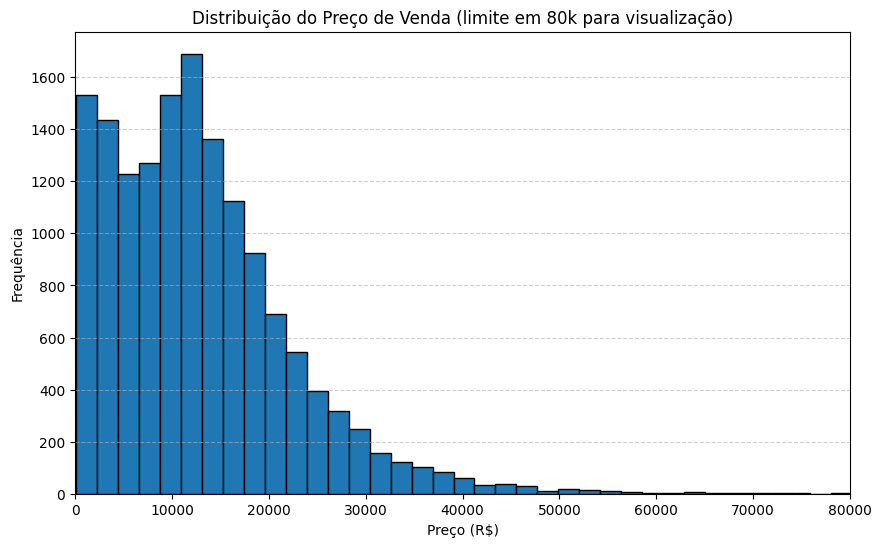

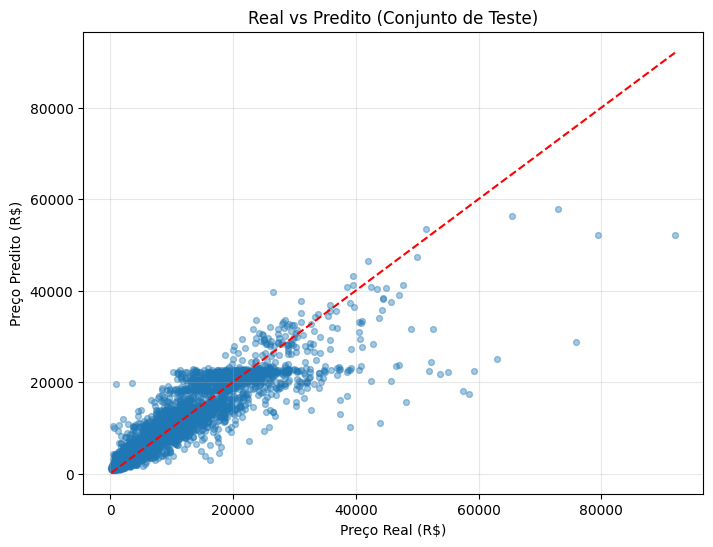

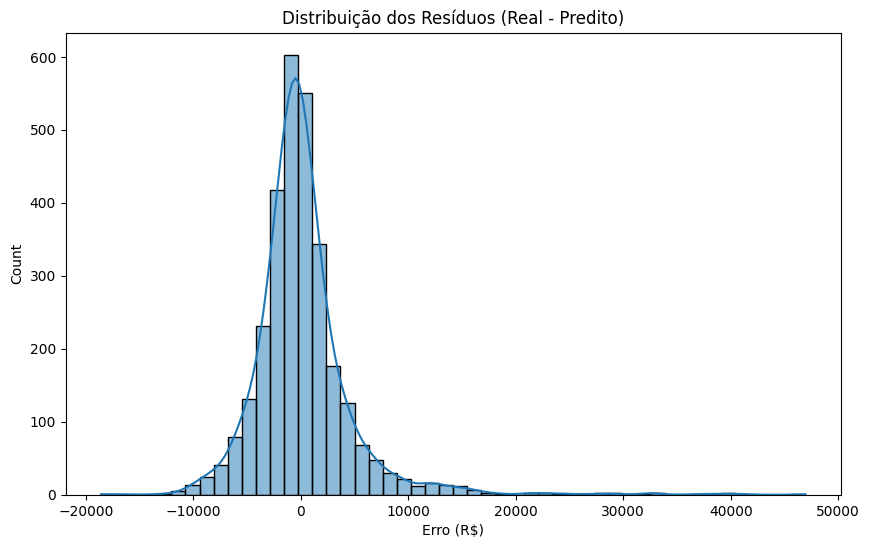

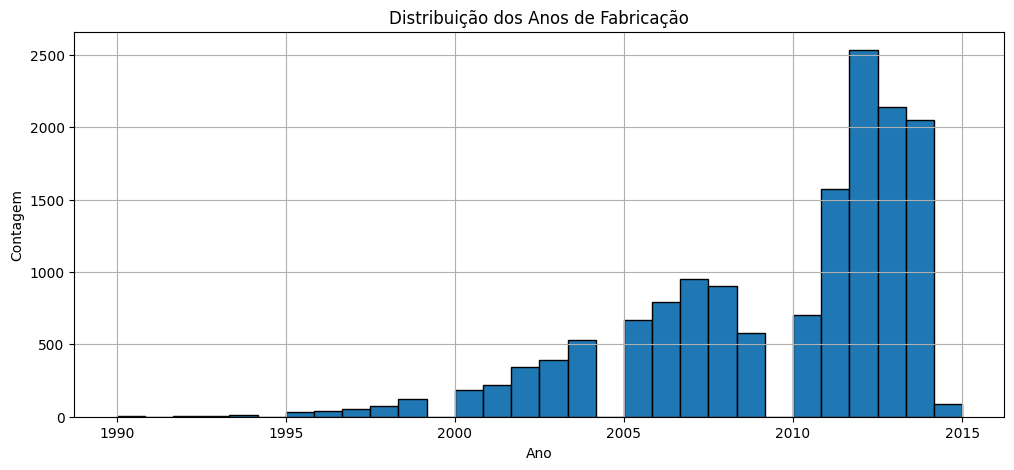

In [20]:
# PASSO 18 - GRÁFICOS (análise visual)
import seaborn as sns

# 1) Distribuição do target (com limite para facilitar leitura)
plt.figure(figsize=(10,6))
plt.hist(df_model[target], bins=60, edgecolor='black')
plt.xlim(0, 80000)
plt.title('Distribuição do Preço de Venda (limite em 80k para visualização)')
plt.xlabel('Preço (R$)')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 2) Real x Predito (teste)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, alpha=0.4, s=18)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Preço Real (R$)')
plt.ylabel('Preço Predito (R$)')
plt.title('Real vs Predito (Conjunto de Teste)')
plt.grid(alpha=0.3)
plt.show()

# 3) Resíduos
residuos = y_test - y_test_pred
plt.figure(figsize=(10,6))
sns.histplot(residuos, bins=50, kde=True)
plt.title('Distribuição dos Resíduos (Real - Predito)')
plt.xlabel('Erro (R$)')
plt.show()

# 4) Distribuição de anos
plt.figure(figsize=(12,5))
df_model['year'].hist(bins=30, edgecolor='black')
plt.title('Distribuição dos Anos de Fabricação')
plt.xlabel('Ano')
plt.ylabel('Contagem')
plt.show()

**Explicação detalhada (Passo 18)**

- Os gráficos ajudam a interpretar métricas numéricas:
  1. Histograma do target (até 80k) mostra concentração e cauda de outliers.
  2. Scatter Real x Predito permite visualizar acertos e erros por faixa de preço; pontos próximos da linha indicam boa previsão.
  3. Histograma dos resíduos mostra se há viés (média não-zero) ou cauda longa (erros extremos).
  4. Histograma dos anos revela a distribuição temporal dos carros na base.

**Por que?**  
Gráficos são essenciais para identificar heteroscedasticidade, outliers, viés sistemático e para comunicar resultados de forma visual.


**PASSO 19**

,feature,importance
7,odometer,0.476715
1,make,0.297499
4,body,0.198565
2,model,0.050392
11,vehicle_age,0.044768
0,year,0.037092
3,trim,0.021703
6,condition,0.019850
10,state,0.000608
9,interior,0.000590


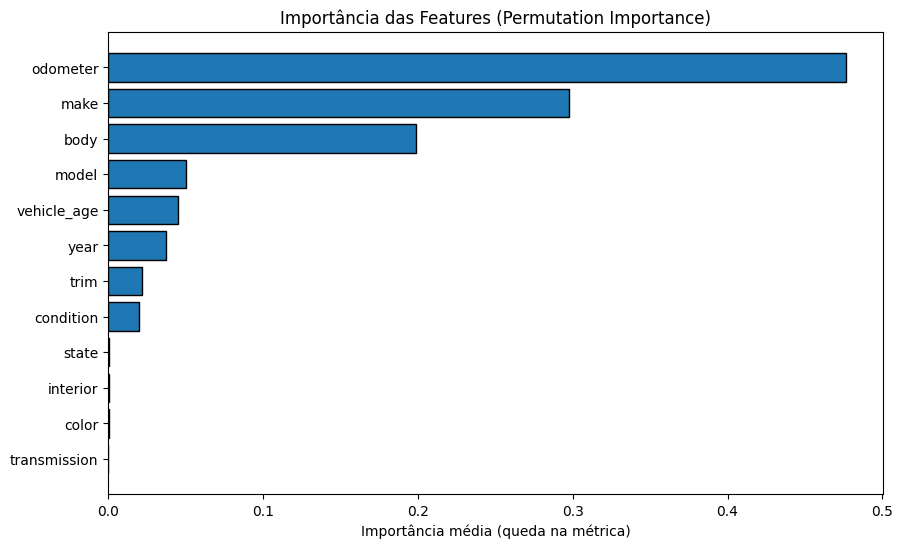

In [19]:
# PASSO 19 - IMPORTÂNCIA DAS FEATURES (Permutation Importance) E CONCLUSÕES
result = permutation_importance(chosen_pipe, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

importances = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

display(importances.head(20))

# Plot top 15
plt.figure(figsize=(10,6))
plt.barh(importances['feature'][:15], importances['importance'][:15], edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Importância das Features (Permutation Importance)')
plt.xlabel('Importância média (queda na métrica)')
plt.show()

**Explicação detalhada (Passo 19)**

- `permutation_importance(...)` — permuta cada feature individualmente no conjunto de teste e mede a queda média na métrica (aqui, a métrica interna do estimator).
- Construímos um DataFrame com as importâncias médias e ordenamos.
- Exibimos as top 20 e plotamos as top 15 para facilitar interpretação.
- Interprete com cuidado: se uma variável tiver muitas colunas derivadas (one-hot), a importância pode estar espalhada entre essas colunas.

**Conclusões práticas**
- Normalmente `vehicle_age`, `odometer` e `make/model` aparecem entre as mais importantes, o que faz sentido para precificação.
- Próximos passos sugeridos: tratar outliers, ajustar hiperparâmetros com mais tempo, testar LightGBM/XGBoost, avaliar log-transform no target se desejar reduzir RMSE.


---

## Recomendações finais e próximos passos (resumo)

1. **Treinar com a base completa** (remova o sample) para obter desempenho final real.
2. **Rodar o RandomizedSearchCV** com maior `n_iter` em máquina com recurso se quiser otimizar hiperparâmetros.
3. **Testar modelos de boosting** (LightGBM / XGBoost) — frequentemente melhores em dados tabulares.
4. **Avaliar transformação do target** (ex.: log) para reduzir heteroscedasticidade e melhorar RMSE.
5. **Analisar manualmente os outliers** detectados (maiores resíduos) para identificar erros de entrada ou casos específicos.
6. **Documentar e versionar** o ambiente (requirements.txt) para reprodutibilidade em produção.

Boa sorte na apresentação — se quiser, eu já executo o notebook aqui (treino rápido) e atualizo métricas no próprio arquivo antes de você subir no Colab.
